# LES Intercomparison Study for Neutral Boundary Layers: Structure Functions

*Last updated: May 2026*


For case setup and physical parameters, see the [Description](NBL_A94_Description.ipynb) notebook.

Longitudinal structure functions $S_q(r) = \langle |f(x+r) - f(x)|^q \rangle$ (orders $q = 1, 2, 3$) of the streamwise velocity $u$ are computed at four height levels near 50 m, 100 m, 250 m, and 500 m. The 1-D structure function is computed along $x$ for each $y$ row and then averaged over $y$. Reference run: `128x128x128_LASDD_SM_SP` at the end of simulation.

> **Note:** This run uses `FGR = 1` (implicit filtering). Only the Nyquist mode is zeroed each timestep, so structure functions are reliable for $r \gt 2\Delta x$.

## Setup

In [8]:
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Output directory

In [9]:
def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate JAXALFA0.1 repository root')

BaseDir = find_repo_root()

RunDir    = BaseDir / 'examples/NBL_A94/runs/128x128x128_LASDD_SM_SP'
OutputDir = RunDir / 'output'

cfg = {}
exec((RunDir / 'Config.py').read_text(), cfg)

### Load 3D fields at end of simulation

In [10]:
T_snapshot = float(cfg['SimTime'])
dt = float(cfg['dt'])
iter_3D = int(T_snapshot / dt)
field_path = OutputDir / f'ALFA_3DFields_Iteration_{iter_3D}.npz'

nx = int(cfg['nx']); ny = int(cfg['ny']); nz = int(cfg['nz'])

if field_path.exists():
    File3D = np.load(field_path)
    u3D = File3D['u']
    print(f'Loaded {field_path.name}  shape: {u3D.shape}')
else:
    print(f'Missing {field_path}; using NaN placeholders.')
    u3D = np.full((nx, ny, nz), np.nan)

Loaded ALFA_3DFields_Iteration_300000.npz  shape: (128, 128, 128)


### Grid parameters

In [11]:
l_x = float(cfg['l_x'])
l_z = float(cfg['l_z'])
dx  = l_x / nx

# Half levels — u
z_u = np.array([(k + 0.5) * l_z / (nz - 1) for k in range(nz)])

# Height levels matching HorizontalCrossSections notebook
target_heights = [50, 100, 250, 500]
k_levels = [int(np.argmin(np.abs(z_u - h))) for h in target_heights]
z_labels  = [f'{z_u[k]:.1f}' for k in k_levels]

print('Height levels (k, z):')
for k, zl in zip(k_levels, z_labels):
    print(f'  k={k:4d}  z={zl} m')
print(f'dx = {dx:.3f} m')

Height levels (k, z):
  k=   1  z=47.2 m
  k=   3  z=110.2 m
  k=   7  z=236.2 m
  k=  15  z=488.2 m
dx = 31.250 m


### Structure function

In [12]:
def StructureFunction1D_LES(X, max_r=None):
    """Compute longitudinal structure functions along axis 0, averaged over axis 1.

    Translated from StructureFunction1D_LES.m (Sukanta Basu, 2024).

    Parameters
    ----------
    X : ndarray (NI, NJ)
        Field slice; axis 0 is the direction of computation (x), axis 1 is averaged over (y).
    max_r : int, optional
        Maximum lag to compute (default: NI-1). Pass NI//4 to limit to the reliable range.

    Returns
    -------
    S : ndarray (3, max_r)  —  S[q-1, r-1] = <|X(x+r) - X(x)|^q>_{x,y}  for q = 1, 2, 3
    rr : ndarray (max_r,)   —  lag indices [1, 2, ..., max_r]
    """
    NI, NJ = X.shape
    if max_r is None:
        max_r = NI - 1
    max_r = min(max_r, NI - 1)
    S = np.zeros((3, max_r))
    for r in range(1, max_r + 1):
        d = np.abs(X[r:, :] - X[:NI - r, :])   # shape (NI-r, NJ)
        S[0, r - 1] = d.mean()
        S[1, r - 1] = (d ** 2).mean()
        S[2, r - 1] = (d ** 3).mean()
    rr = np.arange(1, max_r + 1)
    return S, rr

In [13]:
plt.rcParams.update({
    'text.usetex': True,
    'font.size': 14,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

## Structure Functions of $u$

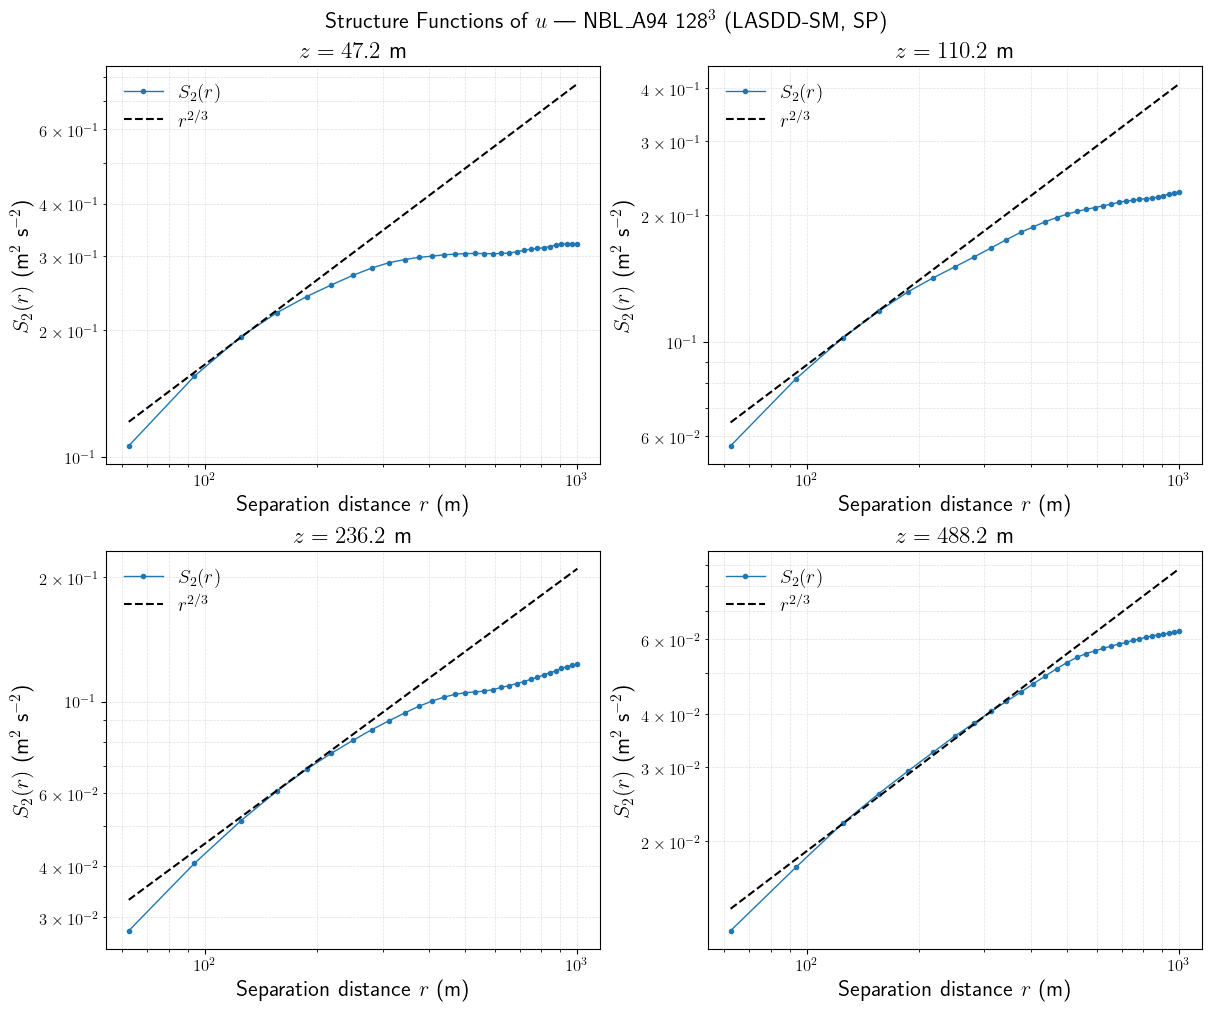

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axs = axs.flatten()

max_r   = nx // 4
min_r   = 2          # skip sub-filter range (FGR=1 zeros only Nyquist, smooth below 2dx)
A_ref_u = [7.7e-3, 4.1e-3, 2.1e-3, 8.8e-4]   # one pre-factor per height level; adjust to shift r^{2/3}

for i, k in enumerate(k_levels):
    S, rr = StructureFunction1D_LES(u3D[:, :, k], max_r=max_r)
    r_m = rr * dx

    ax = axs[i]
    ax.loglog(r_m[min_r-1:], S[1, min_r-1:], color='tab:blue', marker='o',
              markevery=1, markersize=3, linewidth=1.0, label=r'$S_2(r)$')
    ax.loglog(r_m[min_r-1:], A_ref_u[i] * r_m[min_r-1:] ** (2 / 3), 'k--', linewidth=1.5, label=r'$r^{2/3}$')

    ax.set_title(rf'$z = {z_labels[i]}$ m')
    ax.set_xlabel(r'Separation distance $r$ (m)')
    ax.set_ylabel(r'$S_2(r)$ (m$^2$ s$^{-2}$)')
    ax.legend(frameon=False)
    ax.grid(True, which='both', ls='--', alpha=0.4)

fig.suptitle(r'Structure Functions of $u$ — NBL\_A94 128$^3$ (LASDD-SM, SP)', fontsize=16)
plt.show()